
**Завдання 1**: Завантажте дані `medical-charges.csv` в пандас датафрейм і виведіть перші 5 записів. Напишіть, як ви можете підійти до вирішення задачі прогнозування колонки `charges` на основі інших колонок виходячи з наявних на даний момент знань (без ML методів, чисто з використанням аналітики). Запишіть 3 або більше ідей, які приходять вам на думку нижче:

In [13]:
import pandas as pd

df = pd.read_csv("medical-charges.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


1. Куріння може суттєво впливати на медичні витрати. Варто порівняти середні charges у курців і некурців, оскільки курці потенційно частіше потребують медичних послуг.

2. Вік може мати позитивний зв’язок із витратами. Можна подивитися, чи зростає середнє значення charges зі збільшенням age, наприклад розділивши людей на вікові групи.

3. BMI може бути пов’язаний із вищими витратами. Доцільно перевірити, чи люди з більшим індексом маси тіла мають у середньому більші charges.

4. Поєднання куріння та BMI може бути особливо важливим. Наприклад, порівняти витрати курців із високим BMI, курців із нормальним BMI та некурців.

5. Кількість дітей може впливати на витрати. Можна порівняти середні charges у людей без дітей і з різною кількістю дітей.

6. Регіон проживання може мати значення. Варто порівняти середні медичні витрати між регіонами, бо ціни на послуги чи доступ до медицини можуть відрізнятися.

7. Стать теж можна перевірити як можливий фактор. Наприклад, порівняти середні charges у чоловіків та жінок.

**Завдання 2**: Візуалізуйте розподіл медичних зборів (`charges`) у вигляді інтерактивної гістограми plotly з розбиттями за категоріями ознак
1. `sex`
2. `region`

Додайте маржинальний графік у вигляді бокс-плота вгорі по дикретним категоріям ознак.
Скористайтесь прикладом візуалізації з лекції.
Опишіть свої спостереження.

In [2]:
import plotly.express as px

In [3]:
fig = px.histogram(
    df,
    x='charges',
    color='sex',
    marginal='box',
    title='Distribution of Medical Charges by Sex'
)

fig.update_layout(bargap=0.1)
fig.show()

Розподіл медичних витрат є правосторонньо скошеним: більшість клієнтів мають порівняно невеликі витрати, переважно до 15–20 тисяч, але є окремі випадки з дуже високими витратами - понад 40–60 тисяч.

Для чоловіків і жінок розподіли значною мірою перетинаються. Водночас у чоловіків медіана та верхня межа витрат дещо вищі, ніж у жінок. В обох групах є багато викидів із великими медичними витратами.

Отже, стать може мати певний вплив на charges, але за графіком вона навряд чи є головною ознакою для прогнозування.

In [4]:
fig = px.histogram(
    df,
    x='charges',
    color='region',
    marginal='box',
    title='Distribution of Medical Charges by Region'
)

fig.update_layout(bargap=0.1)
fig.show()

У всіх регіонах розподіл charges є правосторонньо скошеним: більшість клієнтів мають відносно невеликі медичні витрати, але є окремі випадки з дуже високими значеннями.

Медіани та основні діапазони витрат у регіонах досить схожі й сильно перетинаються. Це означає, що регіон проживання сам по собі, ймовірно, не пояснює медичні витрати дуже добре.

Найбільші викиди спостерігаються у southeast та northeast, однак високі витрати трапляються в кожному регіоні.

**Завдання 3**: Візуалізуйте з `plotly` розподіл кожного з настуних стовпців відносно того, чи є людина курцем (`smoker`)
- `region`
- `children`

та опишіть коротко свої спостереження.

In [6]:
fig = px.histogram(
    df,
    x='region',
    color='smoker',
    barmode='group',
    title='Distribution of Smokers by Region'
)

fig.show()

In [7]:
fig = px.histogram(
    df,
    x='children',
    color='smoker',
    barmode='group',
    title='Distribution of Smokers by Number of Children'
)

fig.show()

На графіку за регіонами видно, що в кожному регіоні некурців значно більше, ніж курців. Найбільша кількість курців спостерігається в southeast, а в інших регіонах їхня кількість приблизно схожа. Водночас у всіх регіонах співвідношення курців і некурців загалом подібне, тому за цим графіком неможливо зробити висновок про дуже сильну залежність між регіоном проживання та курінням.

На графіку за кількістю дітей найбільше людей не мають дітей, трохи менше мають одну або двох дітей. Кількість людей із трьома, чотирма або п’ятьма дітьми значно менша. У кожній категорії некурців більше, ніж курців. Також не видно чіткої закономірності, що зі збільшенням кількості дітей частка курців систематично зростає або зменшується.

**Завдання 4**: Візуалізуйте звʼязок між стовпцем `charges` та `children` використовуючи графіки-скрипки (`px.violin`). Опишіть свої спостереження.

In [8]:
fig = px.violin(
    df,
    x='children',
    y='charges',
    box=True,
    points='all',
    title='Medical Charges by Number of Children'
)

fig.show()

На графіку не видно чіткої лінійної залежності між кількістю дітей і медичними витратами. Для груп із 0–3 дітьми медіани витрат приблизно схожі, хоча зі збільшенням кількості дітей вони трохи зростають.

У кожній категорії є значний розкид значень і багато високих витрат, особливо серед людей із 0–3 дітьми. Для категорій із 4 і 5 дітьми даних значно менше, тому робити сильні висновки для цих груп складно.

**Завдання 5.** Розглянемо модель для користувачів, які не є курцями (`no_smoker_df`):

$$charges = w \times age + b$$

Спробуйте 3 різні пари параметрів `w` та `b` аби вручну підігнати лінію під дані використовуючи наведені допоміжні функції `estimate_charges` та `try_parameters`. Опишіть спостереження.
Пари параметрів мають бути НЕ такі, як були наведені в лекції.

In [16]:
import matplotlib.pyplot as plt

In [10]:
no_smoker_df = df[df.smoker == 'no']

In [14]:
def estimate_charges(age, w, b):
    return w * age + b

In [15]:
def try_parameters(df, w, b):
    ages = df.age
    target = df.charges

    estimated_charges = estimate_charges(ages, w, b)

    plt.plot(ages, estimated_charges, 'r', alpha=0.9);
    plt.scatter(ages, target, s=8,alpha=0.8);
    plt.xlabel('Age');
    plt.ylabel('Charges')
    plt.legend(['Estimate', 'Actual']);

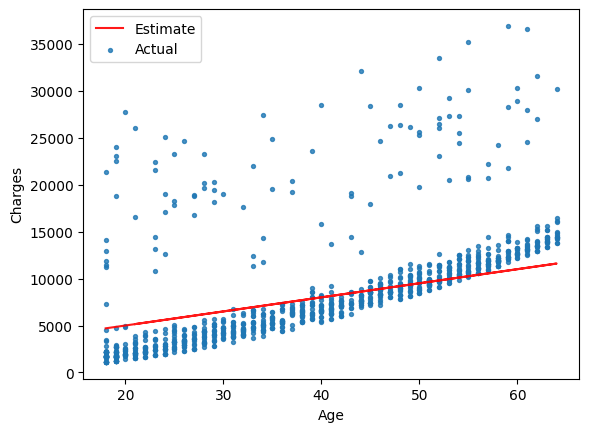

In [17]:
try_parameters(no_smoker_df, 150, 2000)

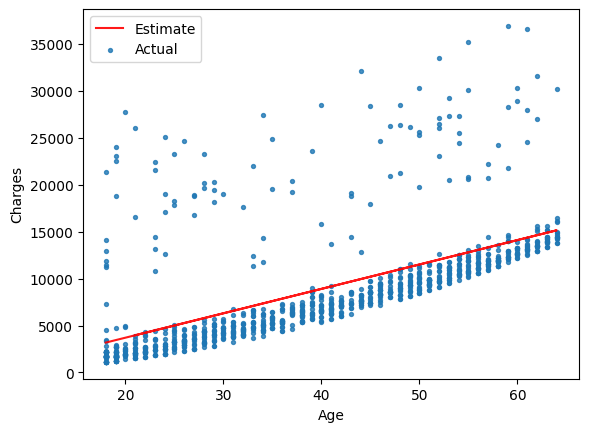

In [18]:
try_parameters(no_smoker_df, 260, -1500)

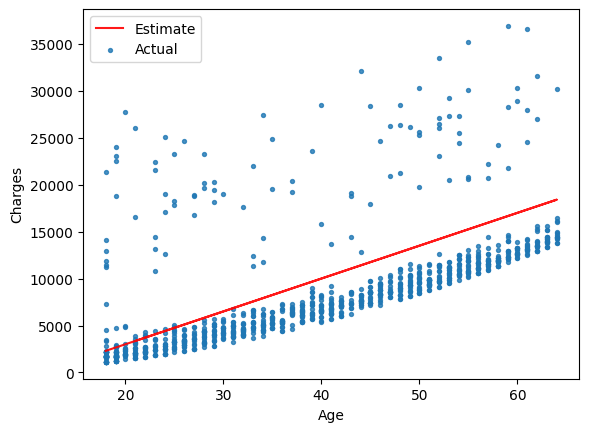

In [19]:
try_parameters(no_smoker_df, 350, -4000)

При w=150, b=2000 пряма є недостатньо крутою та переважно недооцінює медичні витрати старших клієнтів.

При w=350, b=−4000 пряма є занадто крутою і завищує прогнозовані витрати для людей старшого віку.

Найкраще наближення серед перевірених варіантів дає w=260, b=−1500, оскільки ця лінія розташована ближче до основної групи точок.

Водночас у даних є окремі високі значення витрат, які проста модель лише за віком не може добре пояснити.

Отже, для точнішого прогнозу потрібно буде враховувати й інші ознаки, наприклад BMI, кількість дітей або регіон.

**Завдання 6**: Напишіть фукнцію для обчислення root mean squared error згідно з формулою цієї метрики точності моделі з використанням `numpy`.

Обчисліть RMSE для тих пар пареметрів, які Ви спробували в завданні 5.

Яке найнижче значення втрат ви зможете досягти? Чи можете ви придумати загальну стратегію для знаходження кращих значень $w$ та $b$ методом проб та помилок?

In [22]:
import numpy as np

In [23]:
def rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

In [24]:
ages = no_smoker_df.age
actual_charges = no_smoker_df.charges

parameters = [
    (150, 2000),
    (260, -1500),
    (350, -4000)
]

for w, b in parameters:
    predicted_charges = estimate_charges(ages, w, b)
    error = rmse(actual_charges, predicted_charges)

    print(f"w = {w}, b = {b}, RMSE = {error:.2f}")

w = 150, b = 2000, RMSE = 4973.96
w = 260, b = -1500, RMSE = 4673.65
w = 350, b = -4000, RMSE = 4991.99


Для оцінки якості кожної лінійної моделі було обчислено RMSE. Найменше значення RMSE отримано для параметрів w = 260 та b = -1500: приблизно 4673.65. Отже, серед трьох перевірених варіантів ця модель дає найменшу середню помилку прогнозу.

Значення RMSE означає, що прогноз моделі в середньому відрізняється від реальних медичних витрат приблизно на 4674. Можна побачити, що візуально найкраща пряма також має найменший RMSE.

Для пошуку кращих параметрів методом проб і помилок можна перебирати різні значення w і b, обчислювати RMSE для кожної пари та залишати ту пару, у якої помилка найменша. Спочатку можна змінювати параметри великими кроками, а потім перевіряти менші кроки біля найкращого варіанту.

Так, можна автоматично перебирати багато можливих значень w і b. Для кожної пари параметрів потрібно обчислити прогнозовані значення та RMSE, а потім зберегти пару з найменшою помилкою. Спочатку можна використовувати більші кроки для пошуку приблизно найкращої області, а потім зменшити кроки та точніше підібрати параметри біля знайденого варіанту.

Код нижче:

P.S.: для реалізації автоматичного перебору параметрів було використано допомогу ШІ.

In [26]:
best_rmse = float('inf')
best_w = None
best_b = None

for w in range(100, 401, 10):
    for b in range(-5000, 3001, 100):
        predicted_charges = estimate_charges(ages, w, b)
        error = rmse(actual_charges, predicted_charges)

        if error < best_rmse:
            best_rmse = error
            best_w = w
            best_b = b

print("Найкращі параметри:")
print("w =", best_w)
print("b =", best_b)
print("RMSE =", round(best_rmse, 2))

Найкращі параметри:
w = 270
b = -2200
RMSE = 4662.67
